#### Air polution prediction

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Zadanie 1

# Read CSV file - skip columns mentioned in exercise
cols_to_skip = ["No", "wd", "station"]
df = pd.read_csv("PRSA_Data_Wanshouxigong_20130301-20170228.csv", usecols=lambda x: x not in cols_to_skip)

# Create Date column based on existing data from df, set it as index, then drop cols
timeframe_cols = ["year", "month", "day", "hour"]
df["Date"] = pd.to_datetime(df[timeframe_cols])

df = df.set_index("Date")
df = df.drop(labels=timeframe_cols, axis=1)
df.index.freq = "h"

# Interpretation of data: 
# Each row is an hour ranging from 2013-03-01 up to 2017-02-28 (35064 records)

# PM2.5 - microscopic airborne particles (2.5 micrometer diameter) - very easily penetrates the lungs during inhalation and enters bloodstream, one of the most important marker of air polution (µg/m³).
# PM10 - microscopic airborne particles (10 micrometers diameter)  - slightly bigger polutants like mold, dust, soot, can induce adverse health effects (µg/m³). 
# SO2  - Sulfur dioxide concentration in the air (µg/m³).
# NO2 - Nitrogen Dioxide concentration in the air (µg/m³).
# CO - Carbon Monoxide concentration in the air (µg/m³).
# O3 - Ozone concentration in the air (µg/m³).
# TEMP - Temperature in Celcius (C') at given time.
# PRES - Pressure i hectopascal (hPa) at given time.
# DEWP - Dewpoint Temp - the temperature point at which the air can hold no more water (water vapor).
# RAIN - Rain level (millimeters) at given time.
# WSPM - Wind speed (m/s) at given time.

In [ ]:
# Zadanie 2

# Start by showcasing means, stds, and largest and the smallest values from the columns.
df.describe()

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,34368.000000,34580.000000,34395.000000,34310.00000,33767.000000,33986.000000,35045.000000,35045.000000,35045.000000,35045.000000,35051.000000
mean,85.024136,112.223459,17.148603,55.52956,1370.395031,56.229904,13.784477,1011.511804,2.707442,0.064320,1.745314
std,85.975981,97.593210,23.940834,35.80805,1223.139114,57.082710,11.385156,10.570928,13.704139,0.796981,1.206355
min,3.000000,2.000000,0.285600,2.00000,100.000000,0.214200,-16.800000,985.100000,-35.300000,0.000000,0.000000
25%,23.000000,39.000000,3.000000,28.00000,600.000000,8.000000,3.400000,1002.800000,-8.500000,0.000000,0.900000
50%,60.000000,91.000000,8.000000,49.00000,1000.000000,42.000000,14.800000,1011.000000,3.300000,0.000000,1.400000
75%,116.000000,154.000000,21.000000,77.00000,1700.000000,82.000000,23.500000,1020.000000,15.200000,0.000000,2.300000
max,999.000000,961.000000,411.000000,251.00000,9800.000000,358.000000,40.600000,1042.000000,28.500000,46.400000,13.200000


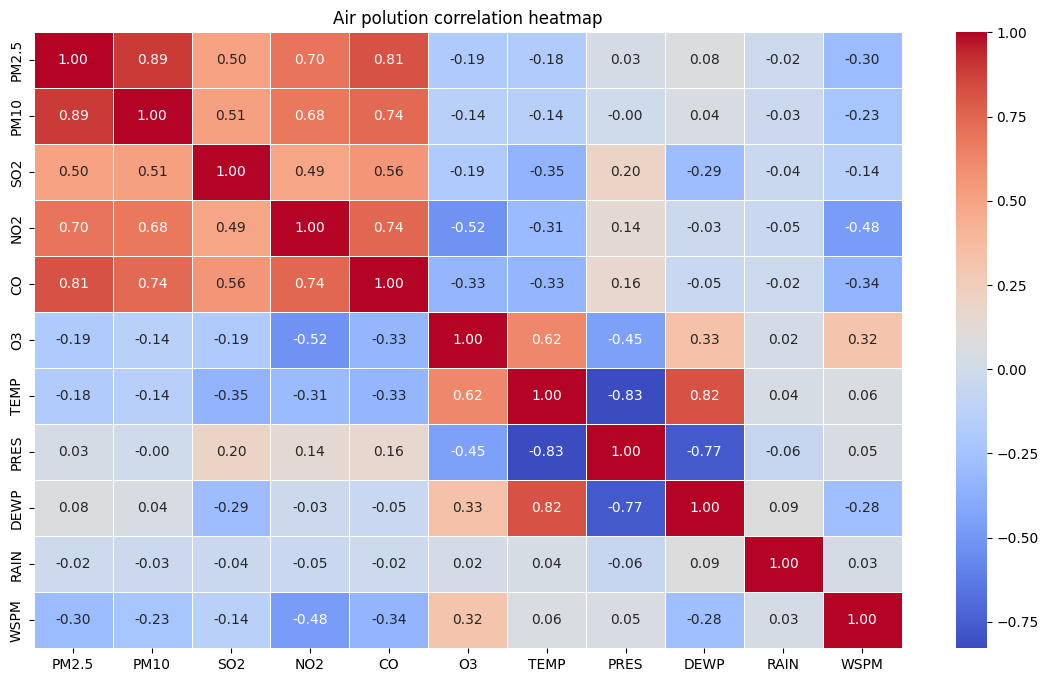

In [ ]:
corr_matrix = df.corr(method="pearson")

plt.figure(figsize=(14,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Air polution correlation heatmap")
plt.show()

# At first glace we can observe very strong correlations sector in the upper left corner. Concentration of polution gases (CO, NO2, SO2) correlates very high with both PM2.5 and PM10.
# Temperature highly correlates with with DEWP, as DEWP informs us if air can store any more water.

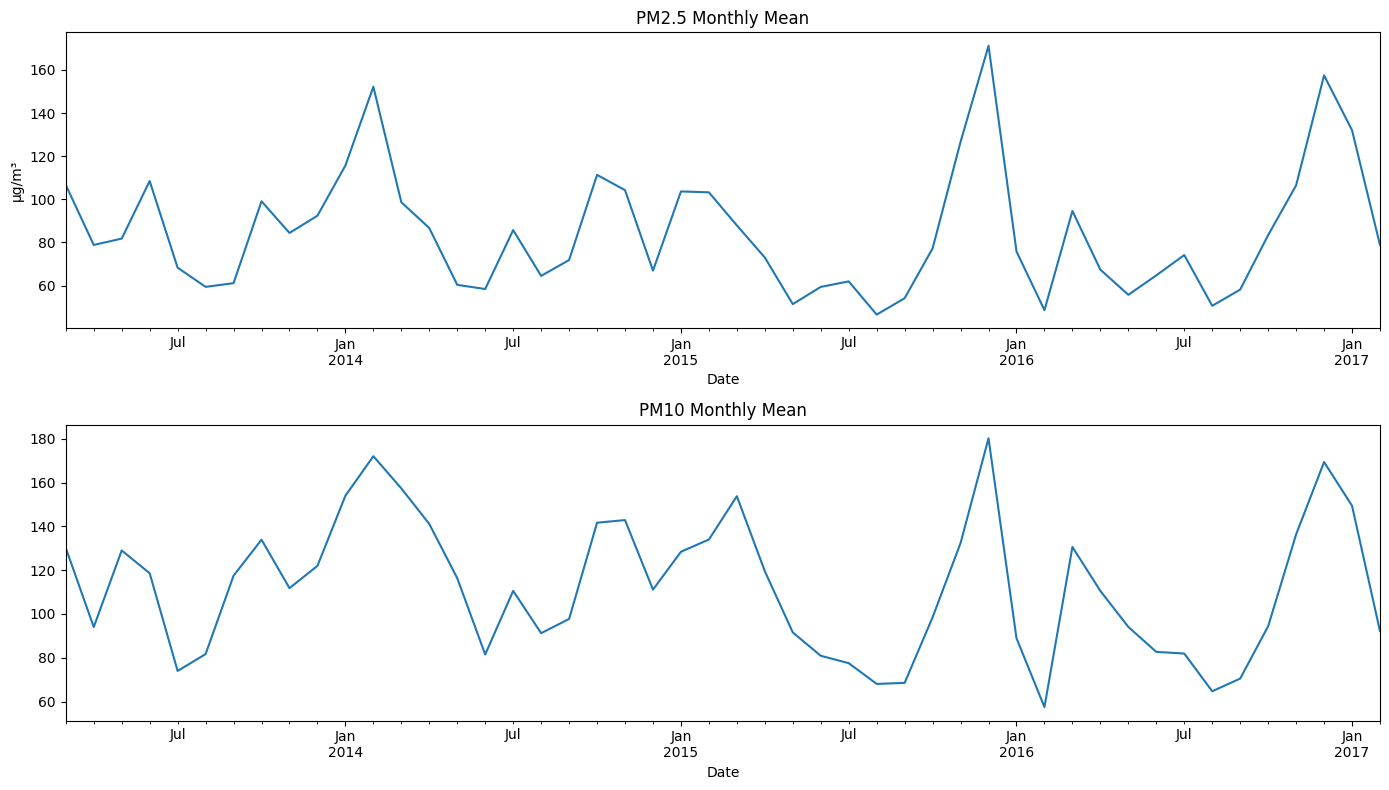

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, figsize=(14,8))

# Decided for better readability to convert data from hourly to monthly using mean
df["PM2.5"].resample("ME").mean().plot(ax=ax1)
df["PM10"].resample("ME").mean().plot(ax=ax2)

ax1.set_title("PM2.5 Monthly Mean")
ax1.set_ylabel("µg/m³")

ax2.set_title("PM10 Monthly Mean")
ax1.set_ylabel("µg/m³")

plt.tight_layout()
plt.show()